In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [74]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [75]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("CooperUnion/anime-recommendations-database")

print("Path to dataset files:", path)

Path to dataset files: /Users/luckyc/.cache/kagglehub/datasets/CooperUnion/anime-recommendations-database/versions/1


In [76]:
#get the anime dataset

anime_data = pd.read_csv("anime.csv")

In [77]:
#get rating dataset
anime_rating = pd.read_csv("rating.csv")

In [78]:
#number of rows and columns in anime dataset
data_shape = anime_data.shape
print(f" The DataFrame has {data_shape[0]} rows and {data_shape[1]} columns! \n")
print(anime_data.info())

 The DataFrame has 12294 rows and 7 columns! 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB
None


In [79]:
#number of rows and colums in rating dataset
rating_shape = anime_rating.shape
print(f" The DataFrame has {rating_shape[0]} rows and {rating_shape[1]} columns! \n")
print(anime_rating.info())

 The DataFrame has 7813737 rows and 3 columns! 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB
None


In [80]:
#top 5 rows 
anime_data.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.370,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.260,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.250,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.170,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.160,151266


In [81]:
#last 5 rows
anime_data.tail()

,anime_id,name,genre,type,episodes,rating,members
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.150,211
12290,5543,Under World,Hentai,OVA,1,4.280,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.880,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.980,175
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,1,5.460,142


In [82]:
# checking min of rating column in anime data dataset
anime_data_min = anime_data["rating"].min()
print(f"The minimum in the anime data dataset for the Rating column is {anime_data_min}")


The minimum in the anime data dataset for the Rating column is 1.67


In [83]:
# checking min of rating column in anime data dataset
anime_data_max = anime_data["rating"].max()
print(f"The maximum in the anime data dataset for the Rating column is {anime_data_max}")


The maximum in the anime data dataset for the Rating column is 10.0


In [84]:
#top 5 rows of rating
anime_rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [85]:
#last 5 rows of rating
anime_rating.tail()

,user_id,anime_id,rating
7813732,73515,16512,7
7813733,73515,17187,9
7813734,73515,22145,10
7813735,73516,790,9
7813736,73516,8074,9


In [86]:
# checking min of rating column in anime rating dataset
anime_rating_min = anime_rating["rating"].min()
print(f"The minimum in the anime rating dataset for the Rating column is {anime_rating_min}")


The minimum in the anime rating dataset for the Rating column is -1


In [87]:
#checking max of rating column in anime rating dataset
anime_rating_max = anime_rating["rating"].max()
print(f"The maximum in the anime rating dataset for the Rating column is {anime_rating_max}")

The maximum in the anime rating dataset for the Rating column is 10


In [88]:
# checking if any values are null in data of anime data
print(anime_data.isnull().any().any())

True


In [89]:
# Getting a count of null values in each column
anime_data.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [90]:
#Displays only rows that contain null values

anime_data[anime_data.isna().any(axis=1)]

,anime_id,name,genre,type,episodes,rating,members
2844,33242,IS: Infinite Stratos 2 - Infinite Wedding,NaN,Special,1,7.150,6604
3541,33589,ViVid Strike!,NaN,TV,12,6.960,12345
6040,29765,Metropolis (2009),NaN,Movie,1,6.270,313
6646,32695,Match Shoujo,NaN,ONA,1,6.020,242
7018,33187,Katsudou Shashin,NaN,Movie,1,5.790,607
...,...,...,...,...,...,...,...
12274,34492,Nuki Doki! Tenshi to Akuma no Sakusei Battle -...,Hentai,OVA,Unknown,NaN,392
12279,34491,Sagurare Otome The Animation,Hentai,OVA,1,NaN,79
12280,34312,Saimin Class,Hentai,OVA,Unknown,NaN,240
12282,34388,Shikkoku no Shaga The Animation,Hentai,OVA,Unknown,NaN,195


In [91]:
#Column names for anime data
anime_data.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [92]:
#using describe for anime data
pd.options.display.float_format = "{:,.3f}".format
anime_data.describe()

,anime_id,rating,members
count,"12,294.000","12,064.000","12,294.000"
mean,"14,058.222",6.474,"18,071.339"
std,"11,455.295",1.027,"54,820.677"
min,1.000,1.670,5.000
25%,"3,484.250",5.880,225.000
50%,"10,260.500",6.570,"1,550.000"
75%,"24,794.500",7.180,"9,437.000"
max,"34,527.000",10.000,"1,013,917.000"


In [93]:
# checking if any values are null in data of anime rating
print(anime_rating.isnull().any().any())

False


In [94]:
anime_rating.isnull().any(axis=0)

user_id     False
anime_id    False
rating      False
dtype: bool

In [95]:
#column names for anime rating
anime_rating.columns

Index(['user_id', 'anime_id', 'rating'], dtype='object')

In [96]:
#using describe for anime rating
pd.options.display.float_format = "{:,.3f}".format
anime_rating.describe()

,user_id,anime_id,rating
count,"7,813,737.000","7,813,737.000","7,813,737.000"
mean,"36,727.957","8,909.072",6.144
std,"20,997.946","8,883.950",3.728
min,1.000,1.000,-1.000
25%,"18,974.000","1,240.000",6.000
50%,"36,791.000","6,213.000",7.000
75%,"54,757.000","14,093.000",9.000
max,"73,516.000","34,519.000",10.000


In [97]:
#convert data columns to title case
anime_data.columns = anime_data.columns.str.title()
anime_data.head(2)

,Anime_Id,Name,Genre,Type,Episodes,Rating,Members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.370,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.260,793665


In [98]:
#convert rating columns to title case
anime_rating.columns = anime_rating.columns.str.title()
anime_rating.head(2)

,User_Id,Anime_Id,Rating
0,1,20,-1
1,1,24,-1


In [99]:
columns_to_drop = ["Episodes", "Members"]

In [100]:
#actually dropping columns and checking first 2 rows

anime_data_drop = anime_data.drop(columns = columns_to_drop)

anime_data_drop.head(2)

,Anime_Id,Name,Genre,Type,Rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.260


In [101]:
# Removing only the NaN / Null values as they appeared in dataset
anime_data_clean = anime_data_drop.dropna(how= "any")
anime_data_clean

,Anime_Id,Name,Genre,Type,Rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.260
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.250
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,9.170
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.160
...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,4.150
12290,5543,Under World,Hentai,OVA,4.280
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4.880
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.980


In [102]:
#displays any nulls that may have not been cleaned. if clean is proper it should be blank

anime_data_clean[anime_data_clean.isna().any(axis=1)]

,Anime_Id,Name,Genre,Type,Rating


In [103]:
anime_data_clean.head()

,Anime_Id,Name,Genre,Type,Rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.260
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.250
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,9.170
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.160


In [104]:
anime_data_clean.tail()

,Anime_Id,Name,Genre,Type,Rating
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,4.150
12290,5543,Under World,Hentai,OVA,4.280
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4.880
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.980
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,5.460


In [105]:
#QUICK math facts of numerical items
anime_data_clean.describe()

,Anime_Id,Rating
count,"12,017.000","12,017.000"
mean,"13,638.001",6.478
std,"11,231.077",1.024
min,1.000,1.670
25%,"3,391.000",5.890
50%,"9,959.000",6.570
75%,"23,729.000",7.180
max,"34,519.000",10.000


In [106]:
#Checking shape of cleaned dataset
anime_data_clean.shape

(12017, 5)

In [107]:
anime_data_clean.head()

,Anime_Id,Name,Genre,Type,Rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.260
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.250
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,9.170
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.160


In [108]:
def filter_by_name(anime_data_clean, search_term):
    # use str.contains() for partial match
    return anime_data_clean[anime_data_clean["Name"].str.contains(search_term, case=False)]

In [109]:
filter_by_name(anime_data_clean, "Stargazer")


,Anime_Id,Name,Genre,Type,Rating
2556,1215,Mobile Suit Gundam Seed C.E.73: Stargazer,"Mecha, Military, Sci-Fi, Space",ONA,7.230


In [110]:
#Attempt to merge dataframes anime_data_clean and anime_rating 
merged_anime = pd.merge(anime_data_clean, anime_rating, on='Anime_Id', how='inner')


In [111]:
merged_anime.shape

(7813611, 7)

In [112]:
#Checking top view
merged_anime.head()

,Anime_Id,Name,Genre,Type,Rating_x,User_Id,Rating_y
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370,99,5
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370,152,10
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370,244,10
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370,271,10
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.370,278,-1


In [113]:
#Checking bottom view

merged_anime.tail()

,Anime_Id,Name,Genre,Type,Rating_x,User_Id,Rating_y
7813606,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.980,39532,-1
7813607,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.980,48766,-1
7813608,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,4.980,60365,4
7813609,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,5.460,27364,-1
7813610,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,5.460,48766,-1


In [114]:
#Removing Duplicates
merged_anime_clean = merged_anime.drop_duplicates(subset="Anime_Id", keep='first')

In [115]:
#Mean of rating_x and rating_y to creating Rating_mean

merged_anime['Rating_Mean']= merged_anime[['Rating_x', 'Rating_y']].mean(axis=1)

In [116]:
cols_to_drop = ["Rating_x", "Rating_y"]

merged_anime_2 = merged_anime.drop(columns = cols_to_drop)



In [117]:
merged_anime_2.head()

,Anime_Id,Name,Genre,Type,User_Id,Rating_Mean
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,99,7.185
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,152,9.685
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,244,9.685
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,271,9.685
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,278,4.185


In [118]:
#Removing Duplicates
merged_anime_clean = merged_anime_2.drop_duplicates(subset="Anime_Id", keep='first')

In [119]:
# Filter the DataFrame for successful projects
filtered_data = merged_anime_clean[merged_anime_clean['Rating_Mean'] >= 7.5]

# Group by Category and State and sum the specified columns
top_anime = filtered_data.groupby(['Anime_Id', 'Name', 'Type'])[[ 'Rating_Mean']].mean().reset_index()

# Sort the entire DataFrame by 'Usd Pledged Real' in descending order
top_anime = top_anime.sort_values(by='Rating_Mean', ascending=False)

top_anime.shape

(1713, 4)

In [120]:


top_10_anime_overall= top_anime.sort_values(by='Rating_Mean', ascending=False).head(10)

top_10_anime_overall


,Anime_Id,Name,Type,Rating_Mean
813,5114,Fullmetal Alchemist: Brotherhood,TV,9.630
215,820,Ginga Eiyuu Densetsu,OVA,9.555
1316,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,Movie,9.550
56,199,Sen to Chihiro no Kamikakushi,Movie,9.465
136,457,Mushishi,TV,9.390
67,245,Great Teacher Onizuka,TV,9.385
1213,11665,Natsume Yuujinchou Shi,TV,9.375
1577,28957,Mushishi Zoku Shou: Suzu no Shizuku,Movie,9.375
1214,11741,Fate/Zero 2nd Season,TV,9.365
363,1535,Death Note,TV,9.355


In [121]:
def sorted_columns(top_anime, search_value):
    #Filter based on search_value in "Type" column
    filtered_top_anime = top_anime[top_anime["Type"].str.contains(search_value, case=False)]
    
    # Sort the filtered dataframe by "Rating_y" highest to lowest
    sorted_top_anime = filtered_top_anime.sort_values(by="Rating_Mean", ascending=False)
    
    return sorted_top_anime



In [122]:
top_anime_tv = sorted_columns(top_anime, "TV").head(10)
top_anime_tv

,Anime_Id,Name,Type,Rating_Mean
813,5114,Fullmetal Alchemist: Brotherhood,TV,9.630
136,457,Mushishi,TV,9.390
67,245,Great Teacher Onizuka,TV,9.385
1213,11665,Natsume Yuujinchou Shi,TV,9.375
1214,11741,Fate/Zero 2nd Season,TV,9.365
363,1535,Death Note,TV,9.355
1146,10379,Natsume Yuujinchou San,TV,9.335
1614,31043,Boku dake ga Inai Machi,TV,9.325
840,5300,Zoku Natsume Yuujinchou,TV,9.320
1118,9989,Ano Hi Mita Hana no Namae wo Bokutachi wa Mada...,TV,9.310


In [123]:
top_anime_movie= sorted_columns(top_anime, "Movie").head(10)
top_anime_movie

,Anime_Id,Name,Type,Rating_Mean
1316,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,Movie,9.550
56,199,Sen to Chihiro no Kamikakushi,Movie,9.465
1577,28957,Mushishi Zoku Shou: Suzu no Shizuku,Movie,9.375
167,578,Hotaru no Haka,Movie,9.290
1075,9260,Kizumonogatari I: Tekketsu-hen,Movie,9.225
1570,28725,Kokoro ga Sakebitagatterunda.,Movie,9.160
1433,20371,Sekaiichi Hatsukoi Movie: Yokozawa Takafumi no...,Movie,9.100
1455,21419,Detective Conan Movie 18: The Sniper from Anot...,Movie,9.085
1442,20815,Sekaiichi Hatsukoi: Valentine-hen,Movie,9.070
1676,32551,Digimon Adventure tri. 3: Kokuhaku,Movie,9.065


In [124]:
top_anime_ova= sorted_columns(top_anime, "OVA").head(10)
top_anime_ova

,Anime_Id,Name,Type,Rating_Mean
215,820,Ginga Eiyuu Densetsu,OVA,9.555
900,6336,Mobile Suit Gundam Unicorn,OVA,9.200
1692,33161,Yahari Ore no Seishun Love Comedy wa Machigatt...,OVA,9.155
1381,17739,Hidamari Sketch: Sae Hiro Sotsugyou-hen,OVA,9.095
606,2952,Final Fantasy VII: Advent Children Complete,OVA,9.085
264,1023,Wolf&#039;s Rain OVA,OVA,9.065
952,7044,Zan Sayonara Zetsubou Sensei Bangaichi,OVA,8.970
359,1520,Black Jack,OVA,8.940
884,6050,Mahou Sensei Negima! Mou Hitotsu no Sekai,OVA,8.925
404,1813,Genshiken OVA,OVA,8.870


In [125]:
top_anime_special= sorted_columns(top_anime, "Special").head(10)
top_anime_special

,Anime_Id,Name,Type,Rating_Mean
1431,20159,Pokemon: The Origin,Special,8.970
935,6862,K-On!: Live House!,Special,8.940
339,1418,Lupin III: Episode 0 &quot;First Contact&quot;,Special,8.890
255,986,Dragon Ball Z Special 1: Tatta Hitori no Saish...,Special,8.875
350,1478,City Hunter: Goodbye My Sweetheart,Special,8.835
1106,9839,Detective Conan: Black History 2,Special,8.825
1640,31553,Charlotte: Tsuyoi Monotachi,Special,8.780
341,1424,Lupin III: Otakara Henkyaku Daisakusen!!,Special,8.775
1628,31324,Grisaia no Meikyuu Special,Special,8.735
522,2488,Mei to Koneko Bus,Special,8.735


In [126]:
top_anime_music= sorted_columns(top_anime, "Music").head(10)
top_anime_music

,Anime_Id,Name,Type,Rating_Mean
197,731,Interstella5555: The 5tory of The 5ecret 5tar ...,Music,9.085
1307,14951,Wonderful Rush,Music,8.700
579,2768,CLAMP in Wonderland 2,Music,8.320
1670,32311,Beautiful World,Music,8.310
1110,9930,Snow Halation,Music,8.305
1149,10445,Perfect Day,Music,8.295
904,6399,Higashi no Eden: Falling Down,Music,8.280
1467,22049,Just Awake,Music,8.260
1711,34252,STAR BEAT!: Hoshi no Kodou,Music,8.195
1710,34240,Shelter,Music,8.190


In [127]:
top_anime_ona= sorted_columns(top_anime, "ONA").head(10)
top_anime_ona

,Anime_Id,Name,Type,Rating_Mean
1680,32668,Noblesse: Awakening,ONA,8.860
1289,14123,Pokemon Black and White 2: Introduction Movie,ONA,8.855
1702,33605,Ling Qi,ONA,8.845
1151,10464,Seitokai no Ichizon Lv.2,ONA,8.740
1675,32543,Lu Shidai 2nd Season,ONA,8.655
628,3167,Eve no Jikan,ONA,8.630
1617,31105,Buddy Complex: Daremo Shiranai Ashita e,ONA,8.535
1559,28431,Pokemon Omega Ruby &amp; Alpha Sapphire: Mega ...,ONA,8.520
1313,15195,Hetalia: The Beautiful World,ONA,8.490
1035,8479,Hetalia World Series,ONA,8.475


In [128]:

top_10_anime_overall= top_anime.sort_values(by='Rating_Mean', ascending=False).head(10)

top_10_anime_overall

,Anime_Id,Name,Type,Rating_Mean
813,5114,Fullmetal Alchemist: Brotherhood,TV,9.630
215,820,Ginga Eiyuu Densetsu,OVA,9.555
1316,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,Movie,9.550
56,199,Sen to Chihiro no Kamikakushi,Movie,9.465
136,457,Mushishi,TV,9.390
67,245,Great Teacher Onizuka,TV,9.385
1213,11665,Natsume Yuujinchou Shi,TV,9.375
1577,28957,Mushishi Zoku Shou: Suzu no Shizuku,Movie,9.375
1214,11741,Fate/Zero 2nd Season,TV,9.365
363,1535,Death Note,TV,9.355


In [129]:
highest_rated = top_anime.sort_values(by='Rating_Mean', ascending=False).head(1)
print(highest_rated)

     Anime_Id                              Name Type  Rating_Mean
813      5114  Fullmetal Alchemist: Brotherhood   TV        9.630


In [130]:
#Checking values

def summarize_top_anime(top_anime) -> str:
    """
    Calculates and summarizes the total, mean, and median number of Rating in 
    Top Anime dataset.

    Parameters:
        top_anime (pandas.DataFrame): The anime dataset containing a 
                                         'Rating_Mean' column.

    Returns:
        str: A formatted string summarizing the total, mean (rounded to 2 decimal places),
            and median number of ratings.
    """
    # Calculate total, mean, and median backers
    top_anime_sum= top_anime["Rating_Mean"].sum().round(2)
    top_anime_mean = top_anime["Rating_Mean"].mean().round(2)
    top_anime_median = top_anime["Rating_Mean"].median().round(2)

    # Return a formatted string
    return (f"The sum of Rating_Mean is {top_anime_sum}\n"
           f"The mean number of Rating_Mean is {top_anime_mean}\n"
           f"The median number of Rating_Mean is {top_anime_median}")

In [131]:
#This is the summary of top_anime dataset ratings (sum, mean, median)
summary_top_anime = summarize_top_anime(top_anime)
print(summary_top_anime)

The sum of Rating_Mean is 13885.34
The mean number of Rating_Mean is 8.11
The median number of Rating_Mean is 8.04


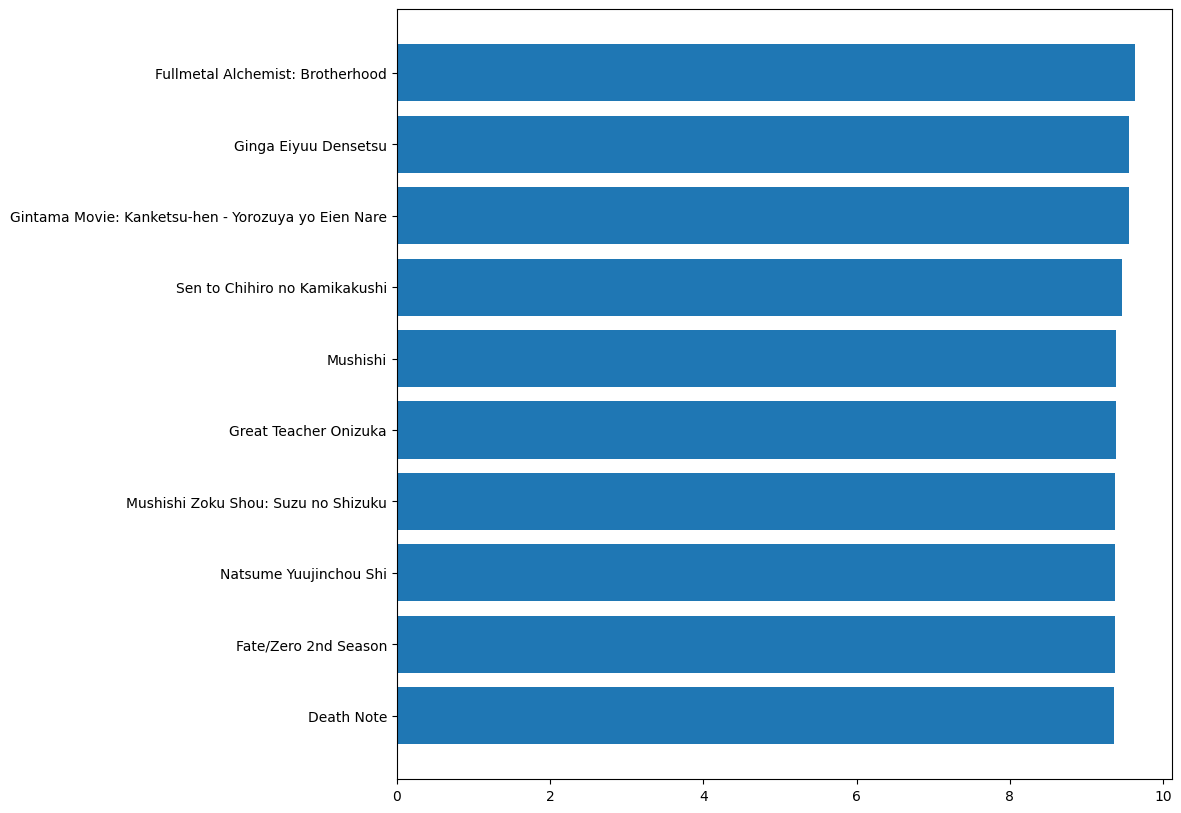

In [132]:

#Sort values for purpose of Horizontal bar graph to display Top Anime and following
top_10_anime_overall_sorted = top_10_anime_overall.sort_values(by="Rating_Mean", ascending=True)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Create the horizontal bar chart with sorted data
bars = plt.barh(top_10_anime_overall_sorted["Name"], top_10_anime_overall_sorted["Rating_Mean"])

# Show the plot
plt.show()

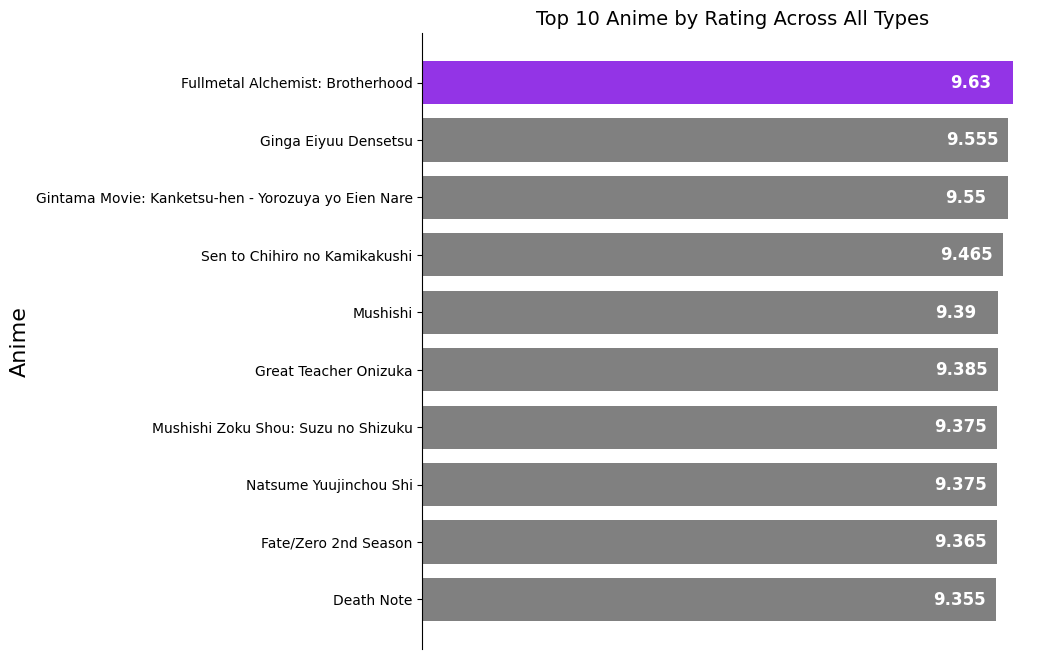

In [133]:
#Function for Charts
#Sort values for purpose of Horizontal bar graph to display Top Anime and following
top_10_anime_overall_sorted = top_10_anime_overall.sort_values(by="Rating_Mean", ascending=True)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 8))

#Attempt to highlight top rated anime
max_rating_value = top_10_anime_overall_sorted['Rating_Mean'].max()
max_rating_name = top_10_anime_overall_sorted[top_10_anime_overall_sorted['Rating_Mean'] == max_rating_value]['Name'].iloc[0]

#colors
highlight_color = "#9334e6"
non_highlight = "#808080"


top_10_anime_overall_sorted['colors'] = top_10_anime_overall_sorted['Name'].apply(lambda x: highlight_color if x == max_rating_name else non_highlight)



# Create the horizontal bar chart with sorted data
bars = plt.barh(top_10_anime_overall_sorted['Name'], top_10_anime_overall_sorted['Rating_Mean'], color=top_10_anime_overall_sorted['colors'], height = .75)

#remove top, bottom and right spines
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.xaxis.set_visible(False)

#Add Bar Labels
ax.bar_label(bars, padding=-45, color="white", fontsize=12, label_type="edge", fontweight="bold")


# Add title and labels
plt.title('Top 10 Anime by Rating Across All Types', fontsize= 14)
plt.xlabel('Rating Mean')
plt.ylabel('Anime', fontsize=16)

# Show the plot
plt.show()

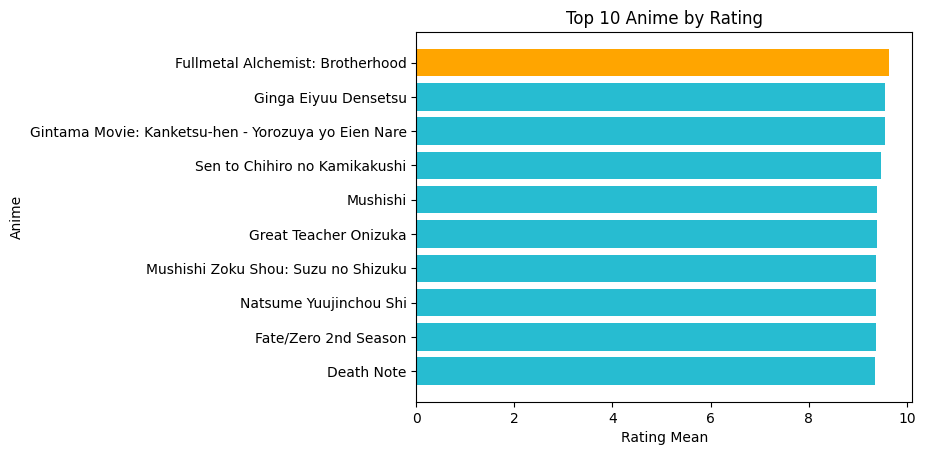

In [134]:
max_rating_value = top_10_anime_overall_sorted['Rating_Mean'].max()
max_rating_name = top_10_anime_overall_sorted[top_10_anime_overall_sorted['Rating_Mean'] == max_rating_value]['Name'].iloc[0]

# Define colors
highlight_color = 'orange'
non_highlight = '#27bcd1'

# Assign colors based on the highest rating
top_10_anime_overall_sorted['colors'] = top_10_anime_overall_sorted['Name'].apply(
    lambda x: highlight_color if x == max_rating_name else non_highlight
)

# Create the horizontal bar chart
plt.barh(top_10_anime_overall_sorted['Name'], top_10_anime_overall_sorted['Rating_Mean'], 
         color=top_10_anime_overall_sorted['colors'])

# Add title and labels
plt.title('Top 10 Anime by Rating')
plt.xlabel('Rating Mean')
plt.ylabel('Anime')

# Show the plot
plt.show()

In [135]:
def plot_ratings(top_10_anime_overall_sorted, rating_mean, search_value, top_ten=10):
    """
    Filters data, ranks by a value column, and plots the top N in a horizontal bar chart.

    Parameters:
    - top_anime: The input DataFrame.
    - rating_mean: The column to rank by.
    - search_value: represents search for different types
    - top_ten: Number of top rows to display.
    - filter_column: Optional column name to filter by (e.g., 'region').
    - filter_value: Value in the filter_column to filter the data on.
    """
    # Optionally filter the data
    #if filter_column and filter_value:
     #   df = df[df[filter_column] == filter_value]

    # Sort the data by the value_column in descending order
    top_anime_sorted = top_anime.sort_values(by="Rating_Mean", ascending=False)

    # Get the top N rankings
    top_ratings = top_anime_sorted.head(top_ten)

    # Plot the horizontal bar chart
    plt.figure(figsize=(10, 6))
    plt.barh(top_ratings.index.astype(str), top_ratings["Rating_Mean"], color='skyblue')
    plt.xlabel("Rating_Mean")
    plt.title(f'Top {top_ten} Rankings Based on {"Rating_Mean"}')
    plt.gca().invert_yaxis()  # To have the highest rank at the top
    plt.show()


plot_ratings(top_anime, "Rating_Mean", top_ten=10)

TypeError: plot_ratings() missing 1 required positional argument: 'search_value'

In [136]:


def plot_top_animes(top_anime: pd.DataFrame) -> None:
    """
    Plots an horizontal bar chart showing the top 10 Anime within a dataset.

    This function generates a bar chart of the top 10 Anime within a dataset, highlighting the
    top anime show with a distinct color (purple), while other Animes are
    shown in grey. It also adds data labels to the bars for better clarity.

    Args:
        top_anime (pd.DataFrame): A DataFrame containing the 'Name' column.

    Returns:
        None: The function generates and displays a bar chart.
    """
    # Count the values in 'species'
    #species_counts = cleaned_rnm['species'].value_counts()
    rating_mean = top_anime["Rating_Mean"].value_counts()
    # Colors to highlight the most popular species
    colors = ['#9334e6' if i == 0 else '#808080' for i in range(len(species_counts))]  # Green for most common species

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax = species_counts.plot.bar(color=colors, ax=ax, width=0.8)

    # Add data labels
    ax.bar_label(ax.containers[0])

    # Title and labels
    plt.title('Species Breakdown from Rick and Morty', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Species')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [138]:

def plot_top_anime(sorted_top_anime):
         
        """
        A helper function that plots a horizontal bar chart.
        
        Parameters:
        - sorted_top_anime: DataFrame containing the ratings.
        - Rating_Mean: The column to plot.
        """

  

        plt.figure(figsize=(10, 10))
        plt.barh(sorted_top_anime.index.astype(str), top_ratings["Rating_Mean"], color='skyblue')
        plt.xlabel("Rating_Mean")
        plt.title(f'Top {top_ten} Animes Based on {"Rating_Mean"}')
        plt.gca().invert_yaxis()  # To have the highest rank at the top
        plt.show()

        plt.figure(figsize=(10, 10))
        plt.barh(data.index.astype(str), data[column_name], color='skyblue')
        plt.xlabel(column_name)
        plt.title(f'Top {top_n} Rankings Based on {column_name}')
        plt.gca().invert_yaxis()  # Highest rank at the top
        plt.show()
    
    # Call the internal plotting function
    
    #create_bar_chart(top_rankings, value_coluns)

    def sorted_columns(top_anime, search_value):

        """
        Main function to filter data, rank by a value column, and plot the top N using an internal plotting function.
        
        Parameters:
        - df: The input DataFrame.
        - value_column: The column to rank by (e.g., 'score', 'sales').
        - top_n: Number of top rows to display (default is 10).
        - filter_column: Optional column name to filter by (e.g., 'region').
        - filter_value: Value in the filter_column to filter the data on.
        """

        #Filter based on search_value in "Type" column
        filtered_top_anime = top_anime[top_anime["Type"].str.contains(search_value, case=False)]
        
        # Sort the filtered dataframe by "Rating_y" highest to lowest
        sorted_top_anime = filtered_top_anime.sort_values(by="Rating_Mean", ascending=False)
        

        return sorted_top_anime

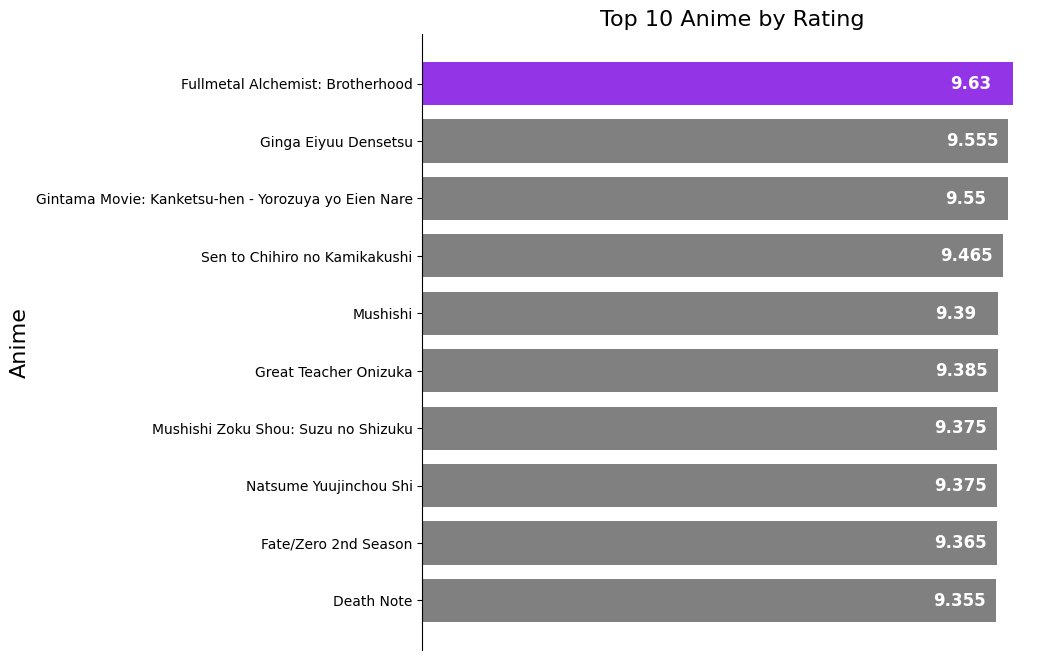

In [144]:
sorted_columns(top_anime, "Movie")
plot_top_anime(top_anime, "Movie")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_rankings(df, value_column, top_n=10, filter_column=None, filter_value=None):
    """
    Main function to filter data, rank by a value column, and plot the top N using an internal plotting function.
    
    Parameters:
    - df: The input DataFrame.
    - value_column: The column to rank by (e.g., 'score', 'sales').
    - top_n: Number of top rows to display (default is 10).
    - filter_column: Optional column name to filter by (e.g., 'region').
    - filter_value: Value in the filter_column to filter the data on.
    """
    
    # Optionally filter the data
    if filter_column and filter_value:
        df = df[df[filter_column] == filter_value]
    
    # Sort the data by the value_column in descending order
    df_sorted = df.sort_values(by=value_column, ascending=False)
    
    # Get the top N rankings
    top_rankings = df_sorted.head(top_n)
    
    # Internal function to plot the horizontal bar chart
    def create_bar_chart(data, column_name):
        """
        A helper function that plots a horizontal bar chart.
        
        Parameters:
        - data: DataFrame containing the top N rankings.
        - column_name: The name of the column to plot.
        """
        plt.figure(figsize=(10, 6))
        plt.barh(data.index.astype(str), data[column_name], color='skyblue')
        plt.xlabel(column_name)
        plt.title(f'Top {top_n} Rankings Based on {column_name}')
        plt.gca().invert_yaxis()  # Highest rank at the top
        plt.show()
    
    # Call the internal plotting function
    create_bar_chart(top_rankings, value_column)


# Example usage:
# Create a sample dataframe
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Score': [88, 92, 95, 85, 91],
    'Region': ['North', 'South', 'North', 'East', 'West']
}
df = pd.DataFrame(data)

# Call the function to plot rankings based on 'Score'
plot_rankings(df, value_column='Score', top_n=3)


In [ ]:
#BarH graph for top 25 Anime overal
#df.plot(x='x', y='y', kind='barh')
#  plt.show()
#def plot_anime(top_anime, "Type": str)
#overall_top_anime_plot = top_10_anime_overall.plot(x= "Name", y='Rating_Mean', kind="barh")
#plt.show()

In [ ]:
#BarH graph for top 25 Anime Type TV
#df.plot(x='x', y='y', kind='barh')
#  plt.show()

#overall_top_anime_plot = top_10_anime_overall.plot(x= "Name", y='Rating_Mean', kind="barh")
#plt.show()

In [ ]:
#BarH graph for top 25 Anime Type Movie
#df.plot(x='x', y='y', kind='barh')
#  plt.show()

#overall_top_anime_plot = top_10_anime_overall.plot(x= "Name", y='Rating_Mean', kind="barh")
#plt.show()

In [ ]:
#BarH graph for top 25 Anime overall Type 
#df.plot(x='x', y='y', kind='barh')
#  plt.show()

#overall_top_anime_plot = top_10_anime_overall.plot(x= "Name", y='Rating_Mean', kind="barh")
#plt.show()

In [ ]:
#BarH graph for top 25 Anime overal
#df.plot(x='x', y='y', kind='barh')
#  plt.show()

#overall_top_anime_plot = top_10_anime_overall.plot(x= "Name", y='Rating_Mean', kind="barh")
#plt.show()

In [ ]:
#BarH graph for top 25 Anime overal
#df.plot(x='x', y='y', kind='barh')
#  plt.show()

#overall_top_anime_plot = top_10_anime_overall.plot(x= "Name", y='Rating_Mean', kind="barh")
#plt.show()